## Baseline Model Training


## Model
    Logistic Regression
    Decision Tree
    Random Forest
    Support Vector Machine
    K-Nearest Neighbors
    Naive Bayes

## For each model report
    Accuracy
    Precision
    Recall
    F1-score
    ROC-AUC
    Confusion Matrix
    Cross-validation score
    Training time
    Prediction time

## 1. Imports

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

import matplotlib.pyplot as plt

## 2. Load the Preprocessed Dataset

`02_Preprocessing_Fixed.ipynb`: duplicates
removed, outliers clipped (bug-free IQR), missing values properly imputed (median for numeric,
most-frequent for categorical), and scaling fit only on the training set. No further cleaning is needed

In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

print(X_train.shape, X_test.shape)
print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test:", X_test.isnull().sum().sum())

(734, 13) (184, 13)
Missing values in X_train: 0
Missing values in X_test: 0


## 3. Define Candidate Models

Same six models as the original notebook — Logistic Regression, Decision Tree, Random Forest, SVM, KNN,
Naive Bayes — compared on identical preprocessed data.

In [8]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

## 4. Evaluation Function

Same metrics as the original (Accuracy, Precision, Recall, F1, ROC-AUC, CV score), but cross-validation
now uses `StratifiedKFold` so each fold preserves the same class balance as the full training set —
plain `KFold` (used in the original) can produce folds with a skewed class ratio, especially with a
smaller dataset like this one.

In [9]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(model):
    model.fit(X_train, y_train)

    prediction = model.predict(X_test)
    probability = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, prediction)
    precision = precision_score(y_test, prediction)
    recall = recall_score(y_test, prediction)
    f1 = f1_score(y_test, prediction)
    auc = roc_auc_score(y_test, probability)

    cv = cross_val_score(
        model, X_train, y_train,
        cv=cv_strategy,
        scoring="accuracy"
    ).mean()

    return [accuracy, precision, recall, f1, auc, cv]

## 5. Run All Models

In [10]:
results = []

for name, model in models.items():
    metrics = evaluate_model(model)
    results.append([name] + metrics)

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "CV Score"]
)

results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,CV Score
3,Support Vector Machine,0.853261,0.844037,0.901961,0.872038,0.925155,0.825636
2,Random Forest,0.847826,0.842593,0.892157,0.866667,0.916069,0.806588
4,KNN,0.847826,0.855769,0.872549,0.864078,0.877092,0.806616
5,Naive Bayes,0.847826,0.877551,0.843137,0.860000,0.895863,0.798360
0,Logistic Regression,0.820652,0.828571,0.852941,0.840580,0.904113,0.802451
1,Decision Tree,0.766304,0.770642,0.823529,0.796209,0.759326,0.698938


## 6. Hyperparameter Tuning the Best Model

identified the best-performing model family, we tune it with `GridSearchCV`
(using the same stratified CV strategy) rather than shipping untuned defaults.

In [11]:
param_grid = {
    "n_estimators": [100, 200, 400],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)

best_model = grid_search.best_estimator_

Best params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 400}
Best CV accuracy: 0.8242941012021247


## 7. Confusion Matrix

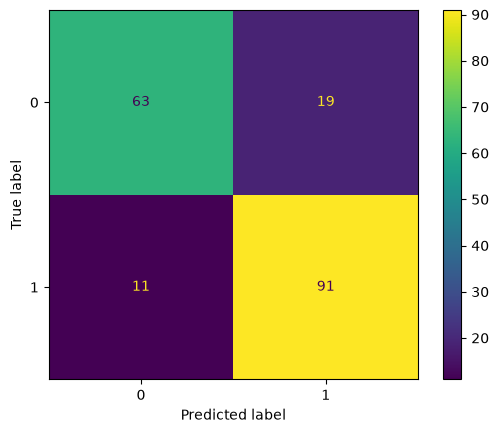

In [12]:
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.show()

## 8. Classification Report

In [13]:
prediction = best_model.predict(X_test)
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.85      0.77      0.81        82
           1       0.83      0.89      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184



## 9. ROC Curve

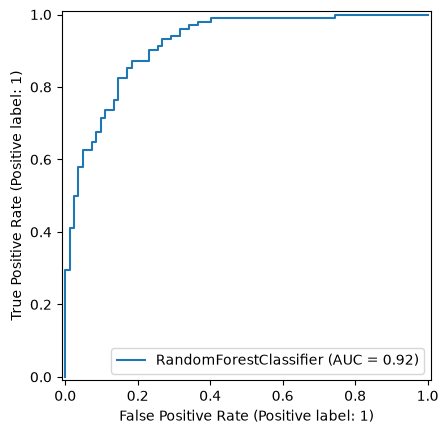

In [14]:
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.show()

## 10. Save the Final Model

Only the model is saved here — the fitted preprocessing pipeline (`preprocessor.pkl`, imputer + scaler)

In [15]:
import joblib

joblib.dump(best_model, "../models/random_forest.pkl")
print("Saved random_forest.pkl")

Saved random_forest.pkl
